In [2]:
import json

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
BASE_PATH = Path('..')
EDGES_PATH = BASE_PATH / 'artifacts' / 'rgrag' / 'rst_relationship_edges.jsonl'

with open(EDGES_PATH, 'r', encoding='utf-8') as file:
    edges = [json.loads(line) for line in file if line.strip()]

df = pd.DataFrame(edges)

In [5]:
df[[
    'relation',
    'nuclearity',
    'rst_span_size',
    'min_tree_distance',
    'average_tree_distance',
    'support_pair_count',
]].describe(include='all')

,relation,nuclearity,rst_span_size,min_tree_distance,average_tree_distance,support_pair_count
count,197513,197513,197513.000000,197513.000000,197513.000000,197513.000000
unique,18,3,NaN,NaN,NaN,NaN
top,Joint,NN,NaN,NaN,NaN,NaN
freq,148044,157554,NaN,NaN,NaN,NaN
mean,NaN,NaN,390.524533,17.468794,18.773105,5.325320
std,NaN,NaN,460.829210,8.141220,8.349454,7.255092
min,NaN,NaN,2.000000,2.000000,2.000000,1.000000
25%,NaN,NaN,76.000000,12.000000,13.000000,2.000000
50%,NaN,NaN,218.000000,17.000000,18.666667,3.000000
75%,NaN,NaN,527.000000,23.000000,24.000000,6.000000


In [7]:
print('Edges:', len(df))
print('Documents:', df['document_id'].nunique())
print('Relationships:', len(set(df['left_relationship_id']) | set(df['right_relationship_id'])))
print('Relationship pairs:', df.apply(
    lambda row: (
        row['document_id'],
        *sorted([row['left_relationship_id'], row['right_relationship_id']])
    ),
    axis=1,
).nunique())

Edges: 197513
Documents: 601
Relationships: 10020
Relationship pairs: 154888


In [8]:
df['min_tree_distance'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

count    197513.000000
mean         17.468794
std           8.141220
min           2.000000
10%           7.000000
25%          12.000000
50%          17.000000
75%          23.000000
90%          28.000000
95%          31.000000
99%          39.000000
max          55.000000
Name: min_tree_distance, dtype: float64

In [9]:
df['rst_span_size'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

count    197513.000000
mean        390.524533
std         460.829210
min           2.000000
10%          17.000000
25%          76.000000
50%         218.000000
75%         527.000000
90%        1097.000000
95%        1498.000000
99%        2002.000000
max        2002.000000
Name: rst_span_size, dtype: float64

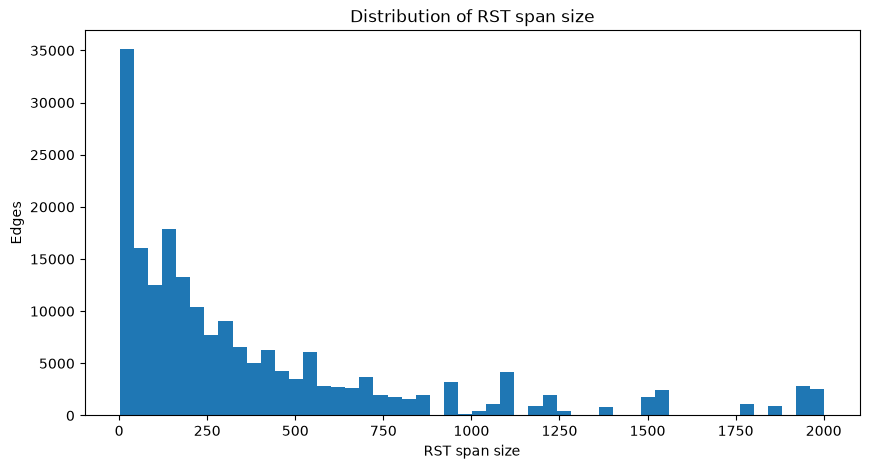

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df['rst_span_size'], bins=50)
plt.xlabel('RST span size')
plt.ylabel('Edges')
plt.title('Distribution of RST span size')
plt.show()

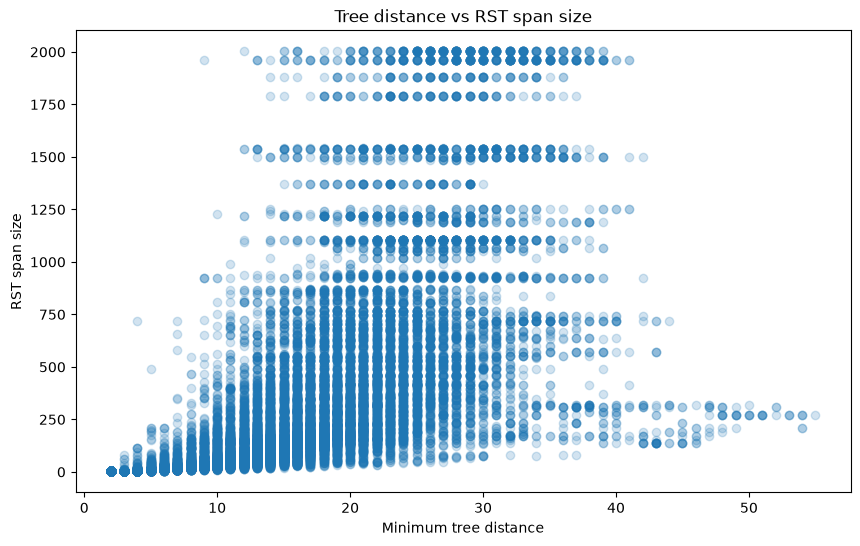

In [12]:
sample = df.sample(min(20000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(
    sample['min_tree_distance'],
    sample['rst_span_size'],
    alpha=0.2,
)
plt.xlabel('Minimum tree distance')
plt.ylabel('RST span size')
plt.title('Tree distance vs RST span size')
plt.show()

In [14]:
relation_stats = (
    df.groupby('relation')
    .agg(
        edges=('relation', 'size'),
        median_distance=('min_tree_distance', 'median'),
        mean_distance=('min_tree_distance', 'mean'),
        median_span=('rst_span_size', 'median'),
        mean_span=('rst_span_size', 'mean'),
    )
    .sort_values('edges', ascending=False)
)

relation_stats

,edges,median_distance,mean_distance,median_span,mean_span
relation,,,,,
Joint,148044,18.0,18.829139,256.0,421.034145
Background,19982,19.0,18.902662,459.0,608.384796
Elaboration,16990,9.0,9.557563,33.0,79.189523
Temporal,5415,11.0,12.214774,70.0,149.833056
Topic-Change,1722,15.0,15.246806,169.0,174.029617
Same-Unit,1244,4.0,4.062701,4.0,4.911576
Attribution,741,4.0,4.697706,5.0,15.021592
TextualOrganization,669,11.0,10.446936,146.0,190.835575
Evaluation,589,8.0,9.249576,22.0,39.110357


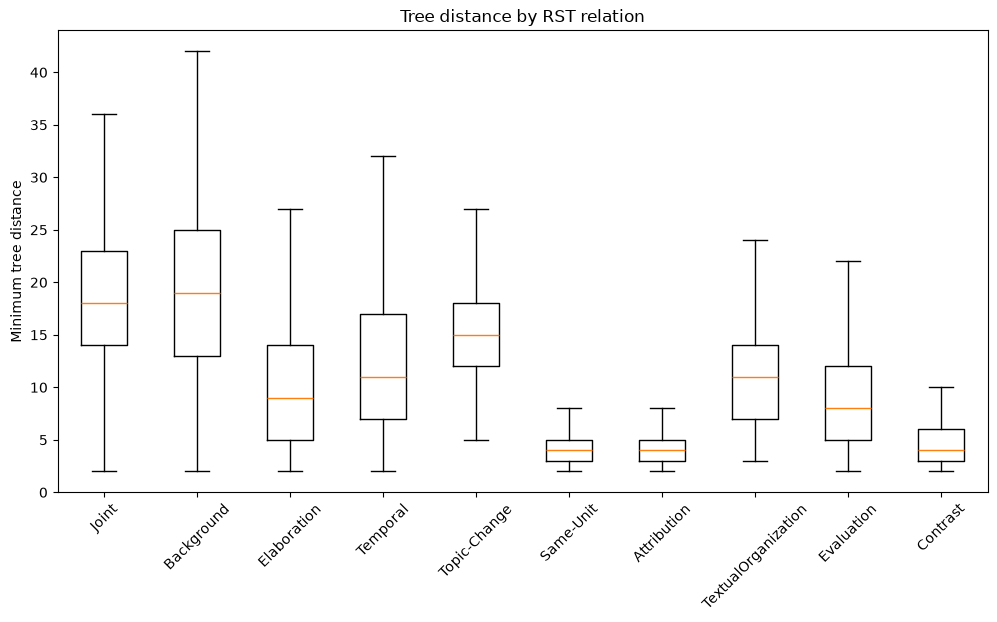

In [24]:
top_relations = df['relation'].value_counts().head(10).index

data = [
    df.loc[df['relation'] == relation, 'min_tree_distance']
    for relation in top_relations
]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=top_relations, showfliers=False)
plt.xticks(rotation=45)
plt.ylabel('Minimum tree distance')
plt.title('Tree distance by RST relation')
plt.show()

In [26]:
thresholds = [2, 4, 6, 8, 10, 12, 16, 20, 24, 32]

rows = []

for threshold in thresholds:
    subset = df[df['min_tree_distance'] <= threshold]

    relationships = (
        set(subset['left_relationship_id'])
        | set(subset['right_relationship_id'])
    )

    pairs = {
        (
            row.document_id,
            *sorted([
                row.left_relationship_id,
                row.right_relationship_id,
            ])
        )
        for row in subset.itertuples()
    }

    rows.append({
        'max_distance': threshold,
        'edges': len(subset),
        'relationship_pairs': len(pairs),
        'relationships_connected': len(relationships),
    })

threshold_df = pd.DataFrame(rows)

threshold_df

,max_distance,edges,relationship_pairs,relationships_connected
0,2,3755,2606,3039
1,4,10576,5909,5603
2,6,18533,10398,7326
3,8,28150,16505,8555
4,10,40029,24761,9297
5,12,54613,35596,9753
6,16,91749,64503,9988
7,20,130527,95775,10019
8,24,161008,121628,10020
9,32,189750,147640,10020


In [27]:
degree = {}

for row in df.itertuples():
    degree.setdefault(row.left_relationship_id, set()).add(row.right_relationship_id)
    degree.setdefault(row.right_relationship_id, set()).add(row.left_relationship_id)

degree_df = pd.DataFrame([
    {
        'relationship_id': relationship_id,
        'degree': len(neighbors),
    }
    for relationship_id, neighbors in degree.items()
])

degree_df['degree'].describe(percentiles=[.5, .75, .9, .95, .99])

count    10020.000000
mean        30.761876
std         26.689327
min          1.000000
50%         21.000000
75%         37.000000
90%         69.000000
95%         91.000000
99%        117.000000
max        254.000000
Name: degree, dtype: float64